## Check sensitivities to parameters

In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
mpl.rcParams['font.family'] = 'sans-serif'
# 優先順位を Helvetica → Arial の順に設定（必要なら他のフォントを追加）
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']    
from param_test import set_param

In [2]:
param_fix_dict = {
    "temp_sea_init_list": [5, 10, 15]    ,
    "BOOL_REEVAP": False, # 十分湿っている雲には返らない
    "temp_surf": [0],
}

## Calc d-excess

In [3]:
def calc_dex(dD, d18O):
    return dD - 8 * d18O

ind=0
title="tuning_parallel"
# title="tuning"
df_HDO = pd.read_csv(f"tables/{title}_HDO_{ind}.csv")
df_H218O = pd.read_csv(f"tables/{title}_H218O_{ind}.csv")

df_dex = df_HDO.copy()
for param in ["snow_delta", "ry_fin_delta", "obs_fin_delta"]:
    df_dex[param] = calc_dex(df_HDO[param], df_H218O[param])

## plot all parameters

In [4]:
def compute_mean(df, y_var, param, param_val):
    vals = df[y_var][df[param] == param_val].replace(-np.inf, np.nan)
    mean = np.nanmean(vals)
    return mean

ylabel_dict = {
    "HDO": "$\mathsf{\delta D}$",
    "H218O": "$\mathsf{\delta ^{18}O}$",
    "dex": "d-excess"
}

ylim_dict = {
    "HDO": (-200,-64),
    "H218O": (-25,-8),
    "dex": (-45,45)
}

def plot_violinplot(df, y_var, param_name, means, ISO_TYPE, title):
    plt.figure(figsize=(6,6))
    plt.title(title)
    ax = sns.violinplot(data=df, y=y_var, hue=param_name)
    mean_labels = [f"{val:.2f}" for val in means]
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [f"{l} (mean={m})" for l, m in zip(labels, mean_labels)]
    ax.legend(handles, new_labels, title=param_name)
    ax.set_ylabel(f"Final water vapor {ylabel_dict[ISO_TYPE]} [‰]")
    ax.set_ylim(ylim_dict[ISO_TYPE])
    plt.show()

def check_sensitivity(df, y_var="obs_fin_delta", ISO_TYPE="HDO", ind=0, SHOW_FIG=True, ALL_PARAM=True, param_fix_dict=param_fix_dict):
    sst_ini = param_fix_dict["temp_sea_init_list"][ind]
    param_test_dict = get_param_test_dict(ISO_TYPE, ALL_PARAM)


    if ALL_PARAM:
        sens_param_list = list(param_test_dict.keys())
        df_filtered = df
    else:    
        sens_param_list, df_filtered = get_sens_param(param_test_dict, df, ind)
    sens_param_list.remove("delta_q_surf")

    mean_dict = {}
    for i, delta_q_surf in enumerate(param_test_dict["delta_q_surf"]):
        df_filtered_delta_q_surf = df_filtered[df_filtered["delta_q_surf"] == delta_q_surf]
        mean_dict[i] = {}
        for param in sens_param_list:
            param_name = param
            if param[-5:] == "_list":
                param_name = param[:-5]
            mean_dict[i][param_name] = {}
            
            try:
                means = []
                for param_val in param_test_dict[param]:
                    param_val_adjusted = param_val
            
                    if isinstance(param_val, list) and len(param_val) >0:                
                        param_val_adjusted = param_val_adjusted[ind]
    
                    means.append(compute_mean(df_filtered_delta_q_surf, y_var, param_name, param_val_adjusted))
        
                    mean_dict[i][param_name][param_val_adjusted] = means[-1]
    
                if SHOW_FIG:
                    title = f"{param_name}\n(temp_sea_init = {sst_ini}, delta_q_surf = {delta_q_surf})"
                    plot_violinplot(df_filtered_delta_q_surf, y_var, param_name, means, ISO_TYPE, title)
                    
            except (ValueError, KeyError, TypeError) as e:
                print(f"Error in {param_name}: {e}")
    
    return mean_dict

def get_sens_param(param_test_dict, df, ind):
    print("Fixed parameters:")
    sens_param_list = []
    for param in param_test_dict.keys():
        
        val_list = param_test_dict[param]
        if len(val_list) > 1:
            sens_param_list.append(param)
        else:
            fixed_val = param_test_dict[param][0]
            
            if param[-5:] == "_list":
                fixed_val = fixed_val[ind]
                param_name = param[:-5]
            else:
                param_name = param
            df = df[df[param_name] != fixed_val]
            print(f"- {param_name}={fixed_val}")
    return sens_param_list, df

def get_param_test_dict(ISO_TYPE, ALL_PARAM=True):
    return set_param("HDO", ALL_PARAM) if ISO_TYPE == "dex" else set_param(ISO_TYPE, ALL_PARAM)
    
def compute_mean_anom_ranking(mean_dict: dict, ISO_TYPE: str, ind: int, param_fix_dict: dict =param_fix_dict) -> pd.DataFrame:

    sst_ini = param_fix_dict["temp_sea_init_list"][ind]
    param_test_dict = get_param_test_dict(ISO_TYPE)

    df_mean_sort = []
    for i, delta_q_surf in enumerate(param_test_dict["delta_q_surf"]):
    
        mean_sort_dict={}
        for param, values in mean_dict[i].items():
            try:
                val_list = list(values.values())
                mean_sort_dict[param] = np.abs(val_list[0]-val_list[-1]) if len(val_list) >= 2 else np.nan

            except KeyError as e:
                print(f"KeyError: {param} -> {e}")
                
        index = f"anom_abs_{ISO_TYPE}_{sst_ini}_{delta_q_surf}"
        df_mean_sort.append(pd.DataFrame(mean_sort_dict, index=[index]).T)
        
    return pd.concat(df_mean_sort, axis=1).sort_values(index, ascending=False)

### dD

In [5]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_HDO = check_sensitivity(df_HDO, y_var="obs_fin_delta", ISO_TYPE="HDO", SHOW_FIG=False, ind=ind)
    display(compute_mean_anom_ranking(mean_dict_HDO, "HDO", ind))
    
    mean_dict_dex = check_sensitivity(df_dex, y_var="obs_fin_delta", ISO_TYPE="dex", SHOW_FIG=False, ind=ind)
    display(compute_mean_anom_ranking(mean_dict_dex, "dex", ind))

,anom_abs_HDO_5_-120,anom_abs_HDO_5_-100
prcp_duration,21.853387,25.767670
temp_air_fin,18.593831,18.593831
resub_factor,11.853933,14.192167
CLOUD_AGING,10.354491,10.354491
prcp_perday,7.132249,8.331679
p_btm,5.092608,5.943042
temp_air_init,4.673840,4.673840
p_top,3.552202,4.141899
dt,1.320178,1.320178
ALPHA_RY_MODE,0.920540,0.920540


,anom_abs_dex_5_-120,anom_abs_dex_5_-100
temp_air_fin,11.246578,12.969049
prcp_duration,8.315471,9.343544
resub_factor,4.924618,5.051227
temp_air_init,4.673558,4.677880
CLOUD_AGING,2.613040,2.983796
prcp_perday,2.893173,2.833989
p_btm,2.035623,2.262323
dt,0.098314,1.556107
p_top,1.262437,1.547964
ALPHA_RY_MODE,0.275593,1.398411


,anom_abs_HDO_10_-120,anom_abs_HDO_10_-100
prcp_duration,21.853387,25.767670
temp_air_fin,18.593831,18.593831
resub_factor,11.853933,14.192167
CLOUD_AGING,10.354491,10.354491
prcp_perday,7.132249,8.331679
p_btm,5.092608,5.943042
p_top,3.552202,4.141899
dt,1.320178,1.320178
ALPHA_RY_MODE,0.920540,0.920540
h_air,0.374007,0.374007


,anom_abs_dex_10_-120,anom_abs_dex_10_-100
temp_air_fin,11.246578,12.969049
prcp_duration,8.315471,9.343544
resub_factor,4.924618,5.051227
CLOUD_AGING,2.613040,2.983796
prcp_perday,2.893173,2.833989
p_btm,2.035623,2.262323
dt,0.098314,1.556107
p_top,1.262437,1.547964
ALPHA_RY_MODE,0.275593,1.398411
rh_surf,0.698694,0.941770


,anom_abs_HDO_15_-120,anom_abs_HDO_15_-100
prcp_duration,21.853387,25.767670
temp_air_fin,18.593831,18.593831
resub_factor,11.853933,14.192167
CLOUD_AGING,10.354491,10.354491
prcp_perday,7.132249,8.331679
p_btm,5.092608,5.943042
p_top,3.552202,4.141899
dt,1.320178,1.320178
ALPHA_RY_MODE,0.920540,0.920540
h_air,0.374007,0.374007


,anom_abs_dex_15_-120,anom_abs_dex_15_-100
temp_air_fin,11.246578,12.969049
prcp_duration,8.315471,9.343544
resub_factor,4.924618,5.051227
CLOUD_AGING,2.613040,2.983796
prcp_perday,2.893173,2.833989
p_btm,2.035623,2.262323
dt,0.098314,1.556107
p_top,1.262437,1.547964
ALPHA_RY_MODE,0.275593,1.398411
rh_surf,0.698694,0.941770


## plot sensitive parameters

Fixed parameters:
- prcp_perday=2
- p_btm=700
- p_top=400
- rh_surf=0.75
- dt=0.5
- ALPHA_RY_MODE=eff
- h_air=1
- surface_wind=6.5
- temp_air_init=5


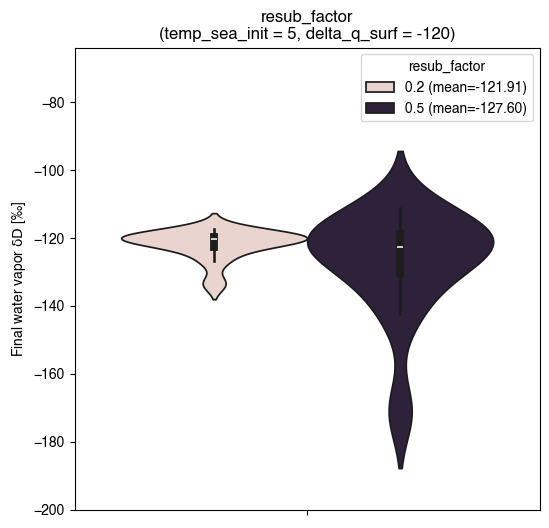

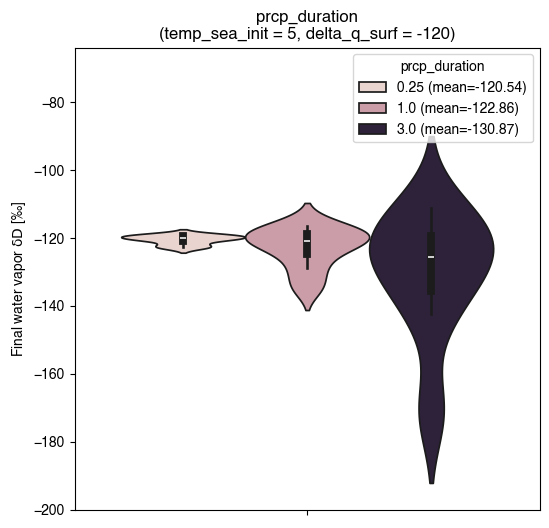

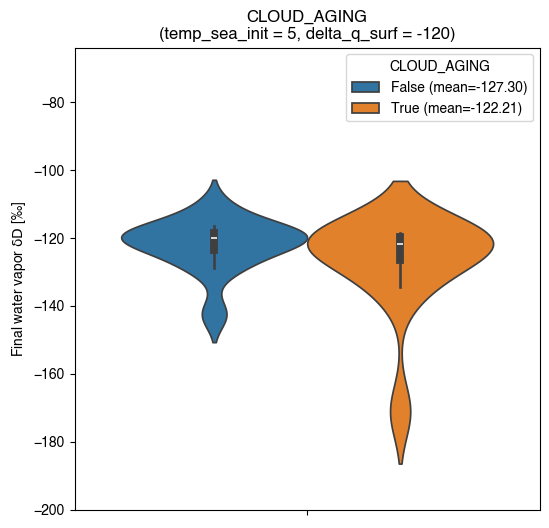

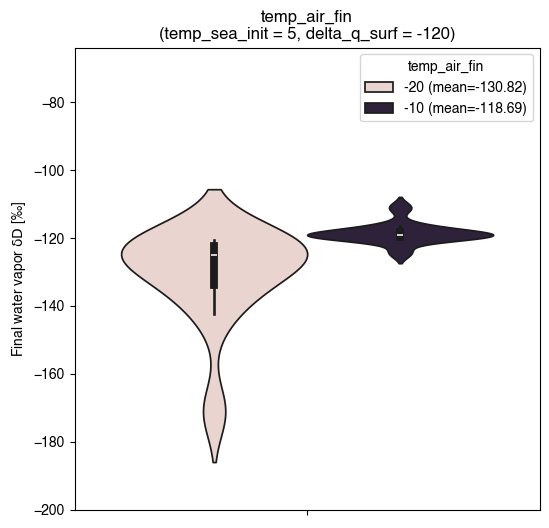

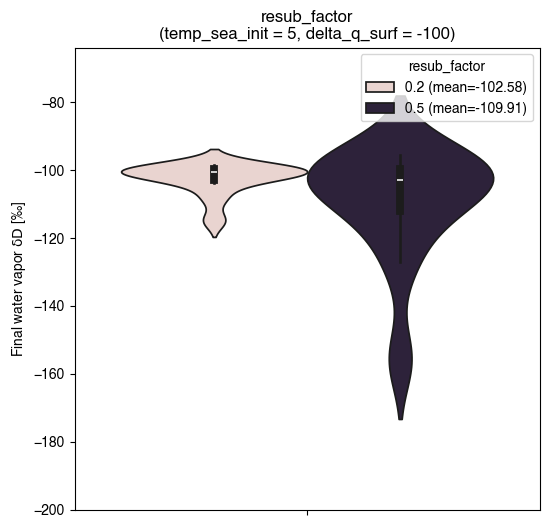

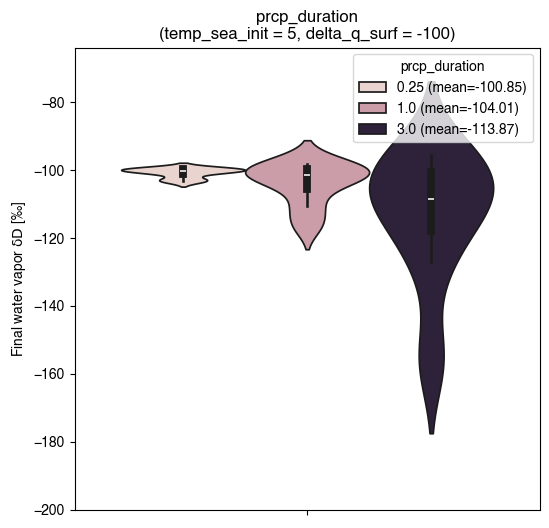

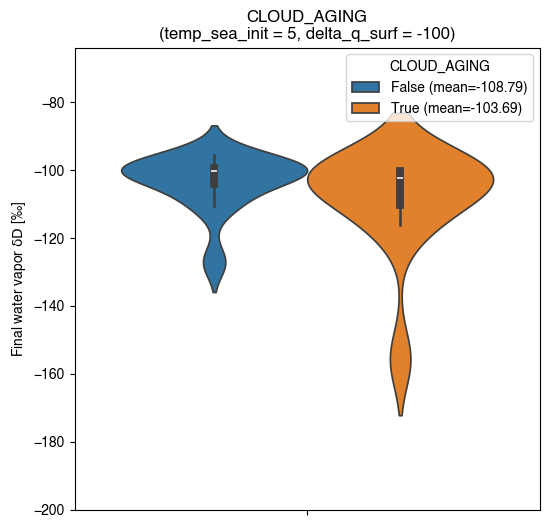

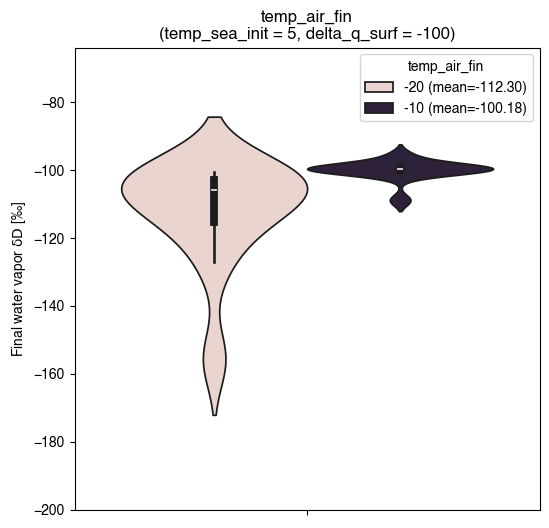

,anom_abs_HDO_5_-120,anom_abs_HDO_5_-100
prcp_duration,10.326208,13.024416
temp_air_fin,12.121556,12.121556
resub_factor,5.694444,7.331764
CLOUD_AGING,5.098457,5.098457


In [6]:
ind=0
mean_dict_dD_sel = check_sensitivity(df_HDO, y_var="obs_fin_delta", 
                                  ISO_TYPE="HDO", ind=ind, ALL_PARAM=False)
compute_mean_anom_ranking(mean_dict_dD_sel, "HDO", ind=ind)

Fixed parameters:
- prcp_perday=2
- p_btm=700
- p_top=400
- rh_surf=0.75
- dt=0.5
- ALPHA_RY_MODE=eff
- h_air=1
- surface_wind=6.5
- temp_air_init=5


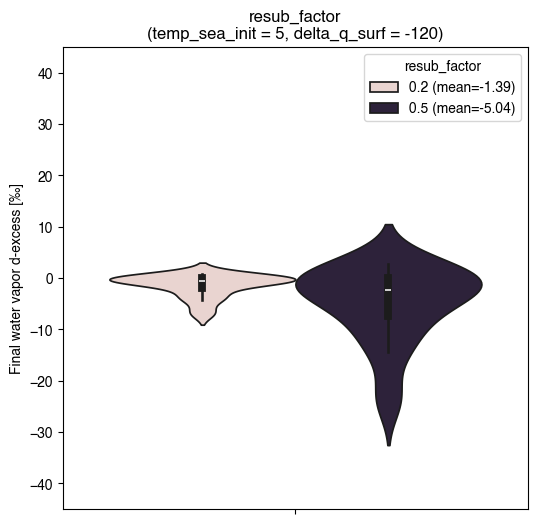

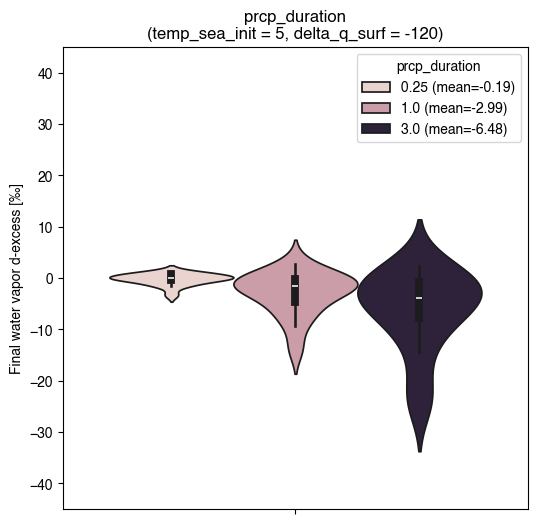

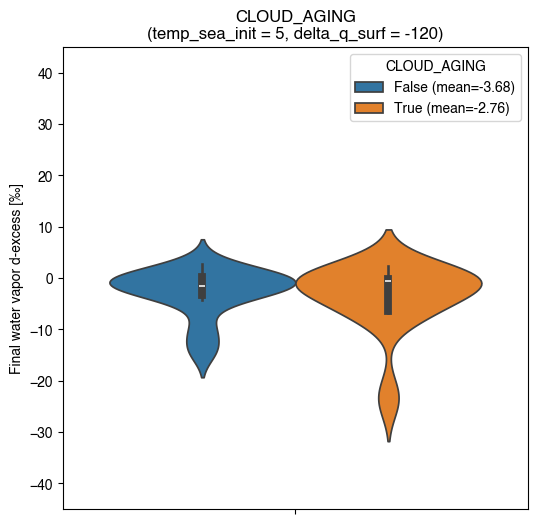

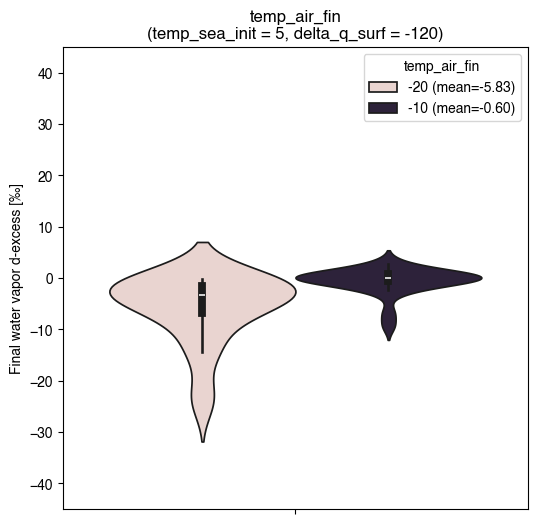

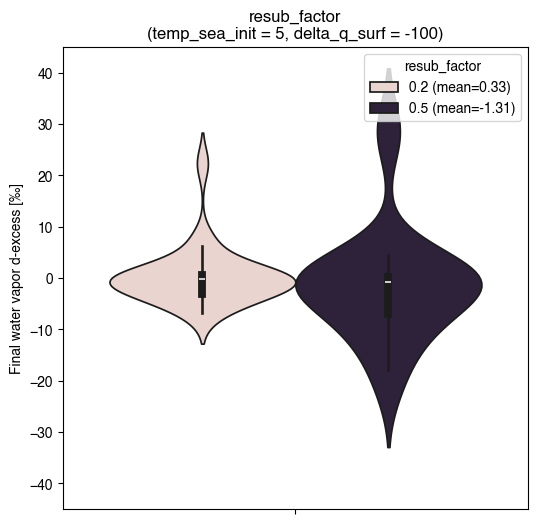

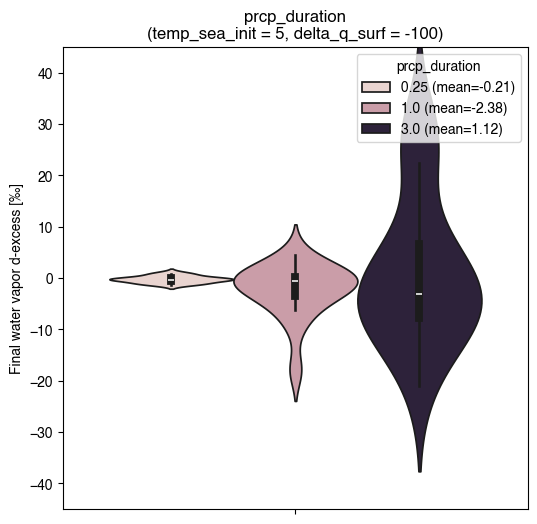

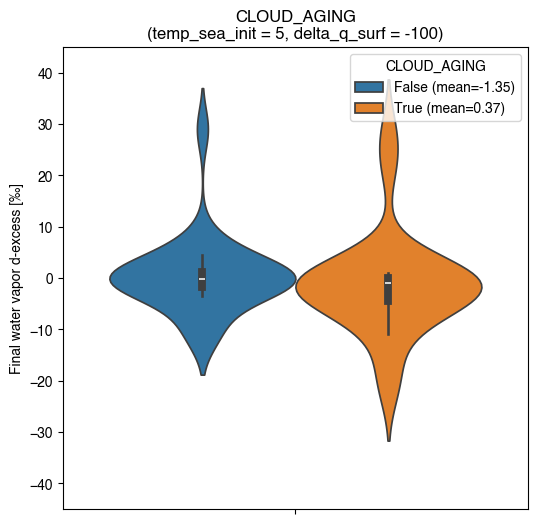

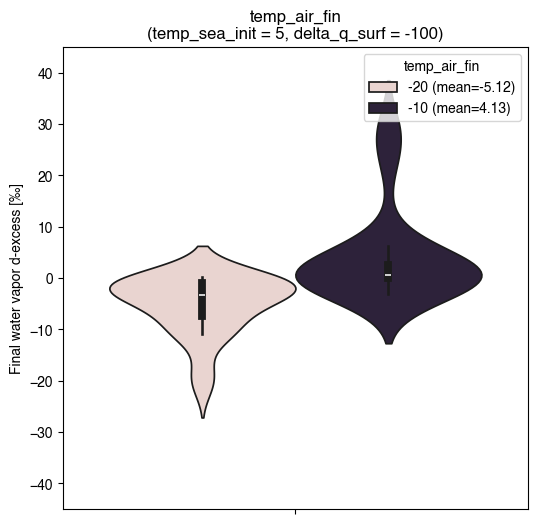

,anom_abs_dex_5_-120,anom_abs_dex_5_-100
temp_air_fin,5.226794,9.248440
CLOUD_AGING,0.918667,1.726730
resub_factor,3.646505,1.637470
prcp_duration,6.288228,1.327242


In [7]:
ind=0
mean_dict_dex_sel = check_sensitivity(df_dex, y_var="obs_fin_delta", 
                                  ISO_TYPE="dex", ind=ind, ALL_PARAM=False)
compute_mean_anom_ranking(mean_dict_dex_sel, "dex", ind=ind)